# E-commerce Conversion Funnel Analysis

**SyntecxHub Data Analytics Internship — Project 2**

### Objective
Analyze the e-commerce conversion funnel from **Browse → Add to Cart → Checkout → Purchase**, quantify conversion and drop-off at each stage, identify bottlenecks, and provide business recommendations.

### Tools
Python • Pandas • NumPy • Matplotlib • Seaborn • Jupyter Notebook

### Dataset
`funnel_analysis_data.csv` contains session-level event records for October 2025 with user, session, event, timestamp, device, region, channel, product category, revenue, and bounce information.

## 1. Import Libraries

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

## 2. Load Dataset

In [36]:
df = pd.read_csv("funnel_analysis_data.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Dataset shape: 21,663 rows × 10 columns


,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.00,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.00,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.00,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.00,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.00,No


## 3. Data Understanding & Quality Check

In [37]:
df.info()

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing"))

print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Unique users: {df['User_ID'].nunique():,}")
print(f"Unique sessions: {df['Session_ID'].nunique():,}")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(f"Date range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")

display(df["Event"].value_counts().rename_axis("Event").to_frame("Records"))


<class 'pandas.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           21663 non-null  str    
 1   Session_ID        21663 non-null  str    
 2   Event             21663 non-null  str    
 3   Timestamp         21663 non-null  str    
 4   Device            21663 non-null  str    
 5   Region            21663 non-null  str    
 6   Channel           21663 non-null  str    
 7   Product_Category  21663 non-null  str    
 8   Revenue           21663 non-null  float64
 9   Bounce_Flag       21663 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.7 MB

Missing values:


,Missing
User_ID,0
Session_ID,0
Event,0
Timestamp,0
Device,0
Region,0
Channel,0
Product_Category,0
Revenue,0
Bounce_Flag,0


Duplicate rows: 0
Unique users: 10,000
Unique sessions: 10,000
Date range: 2025-10-01 to 2025-10-31


,Records
Event,
Browse,10000
Add to Cart,7059
Checkout,3524
Purchase,1080


## 4. Exploratory Analysis

In [38]:
for col in ["Device", "Region", "Channel", "Product_Category", "Bounce_Flag"]:
    print(f"\n{col}")
    display(df[col].value_counts().rename_axis(col).to_frame("Count"))

print("\nTotal revenue from purchase events:")
total_revenue = df.loc[df["Event"] == "Purchase", "Revenue"].sum()
orders = (df["Event"] == "Purchase").sum()
avg_order_value = df.loc[df["Event"] == "Purchase", "Revenue"].mean()

print(f"Revenue: ${total_revenue:,.2f}")
print(f"Purchases: {orders:,}")
print(f"Average order value: ${avg_order_value:,.2f}")


Device


,Count
Device,
Tablet,7237
Desktop,7235
Mobile,7191



Region


,Count
Region,
West,5462
North,5428
East,5391
South,5382



Channel


...


Product_Category


,Count
Product_Category,
Electronics,4405
Fashion,4400
Sports,4348
Beauty,4280
Home,4230



Bounce_Flag


,Count
Bounce_Flag,
Yes,17343
No,4320



Total revenue from purchase events:
Revenue: $1,176,405.78
Purchases: 1,080
Average order value: $1,089.26


## 5. Define the Funnel

For this dataset, each session can contain one record for each funnel stage:

**Browse → Add to Cart → Checkout → Purchase**

The dataset contains exactly 10,000 browse sessions, which gives us the top-of-funnel baseline.

In [39]:
stage_order = ["Browse", "Add to Cart", "Checkout", "Purchase"]

# Count unique sessions reaching each stage
stage_counts = (
    df.groupby("Event")["Session_ID"]
      .nunique()
      .reindex(stage_order)
      .fillna(0)
      .astype(int)
      .rename("Users")
      .reset_index()
)

stage_counts

,Event,Users
0,Browse,10000
1,Add to Cart,7059
2,Checkout,3524
3,Purchase,1080


## 6. Conversion Rate & Drop-off Analysis

In [40]:
stage_counts["Conversion_Rate"] = (
    stage_counts["Users"] / stage_counts["Users"].iloc[0] * 100
)

stage_counts["Previous_Stage_Users"] = stage_counts["Users"].shift(1)
stage_counts["Stage_to_Stage_Conversion"] = (
    stage_counts["Users"] / stage_counts["Previous_Stage_Users"] * 100
)
stage_counts["Stage_to_Stage_Conversion"] = (
    stage_counts["Stage_to_Stage_Conversion"].fillna(100)
)

stage_counts["Drop_off_Users"] = (
    stage_counts["Previous_Stage_Users"] - stage_counts["Users"]
).fillna(0).astype(int)

stage_counts["Drop_off_Rate"] = np.where(
    stage_counts["Previous_Stage_Users"].isna(),
    0,
    100 - stage_counts["Stage_to_Stage_Conversion"]
)

display(stage_counts.round(2))

overall_conversion = stage_counts.loc[
    stage_counts["Event"] == "Purchase", "Users"
].iloc[0] / stage_counts["Users"].iloc[0] * 100

print(f"Overall funnel conversion rate: {overall_conversion:.2f}%")

,Event,Users,Conversion_Rate,Previous_Stage_Users,Stage_to_Stage_Conversion,Drop_off_Users,Drop_off_Rate
0,Browse,10000,100.00,NaN,100.00,0,0.00
1,Add to Cart,7059,70.59,"10,000.00",70.59,2941,29.41
2,Checkout,3524,35.24,"7,059.00",49.92,3535,50.08
3,Purchase,1080,10.80,"3,524.00",30.65,2444,69.35


Overall funnel conversion rate: 10.80%


## 7. Funnel Visualization

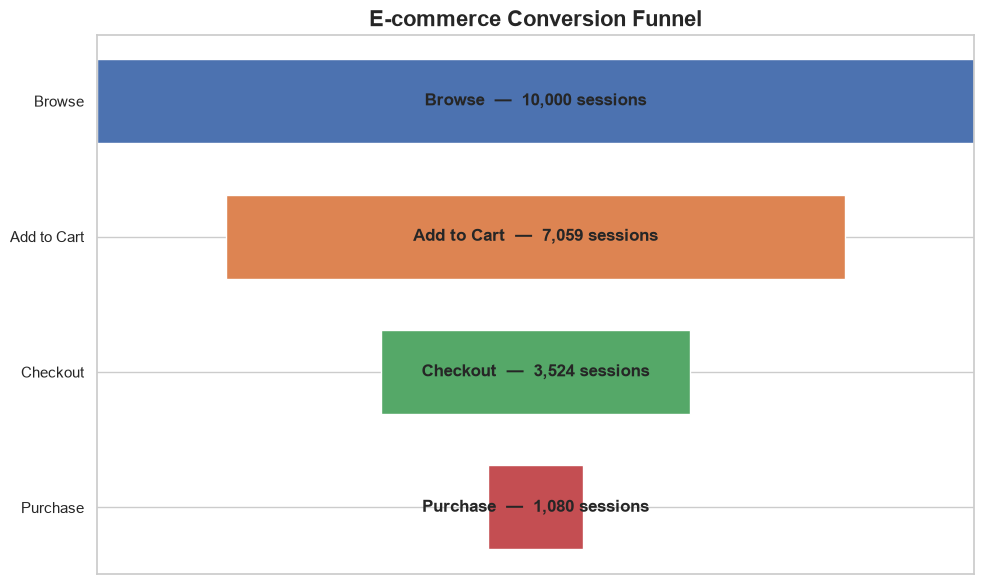

In [41]:
plt.figure(figsize=(10, 6))

users = stage_counts["Users"].values
stages = stage_counts["Event"].values
max_users = users[0]

for i, (stage, count) in enumerate(zip(stages, users)):
    width = count / max_users
    left = (1 - width) / 2
    plt.barh(i, width, left=left, height=0.62)
    plt.text(0.5, i, f"{stage}  —  {count:,} sessions",
             ha="center", va="center", fontweight="bold")

plt.yticks(range(len(stages)), stages)
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.xticks([])
plt.title("E-commerce Conversion Funnel", fontsize=16, fontweight="bold")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 8. Stage-to-Stage Conversion Rates

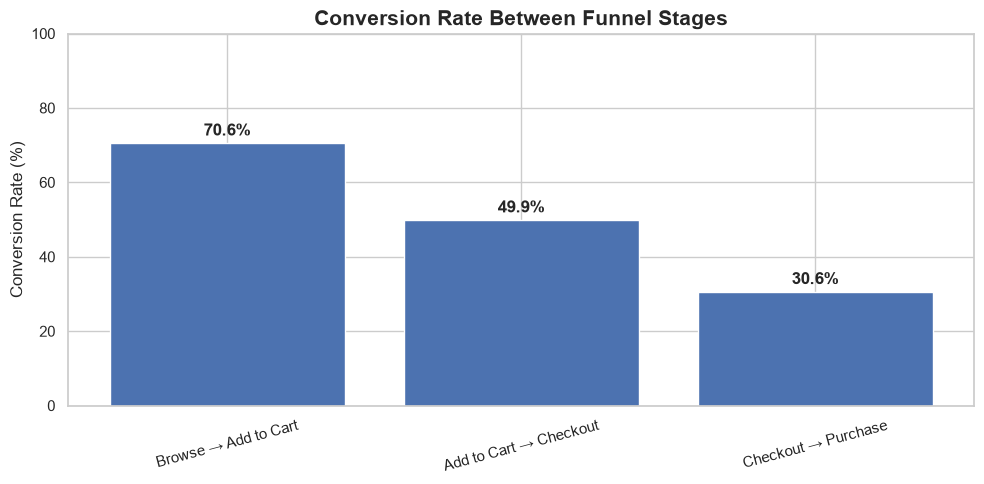

In [42]:
conversion_plot = stage_counts.iloc[1:].copy()
conversion_plot["Transition"] = [
    "Browse → Add to Cart",
    "Add to Cart → Checkout",
    "Checkout → Purchase"
]

plt.figure(figsize=(10, 5))
x = np.arange(len(conversion_plot))
values = conversion_plot["Stage_to_Stage_Conversion"].values
plt.bar(x, values)
plt.xticks(x, conversion_plot["Transition"], rotation=15)
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 100)
plt.title("Conversion Rate Between Funnel Stages", fontsize=15, fontweight="bold")

for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 9. Drop-off Analysis

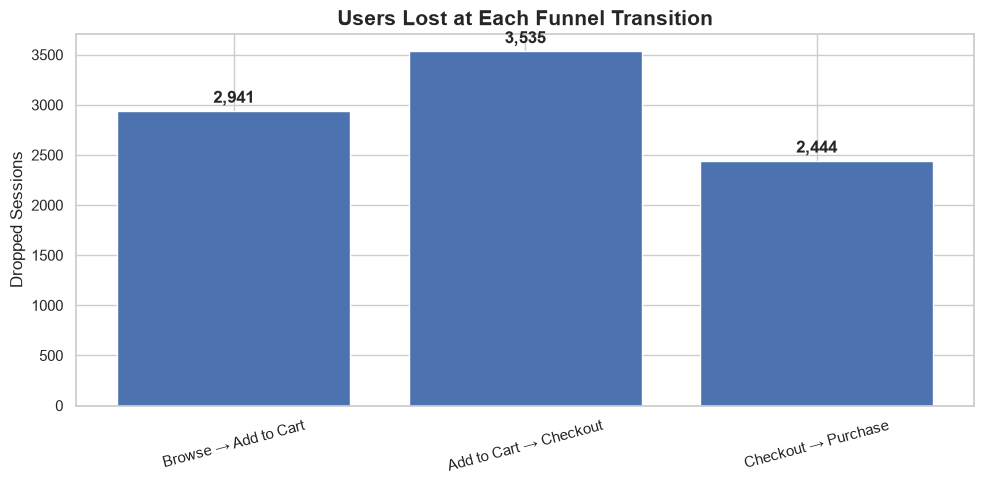

In [43]:
drop_df = stage_counts.iloc[1:].copy()
drop_df["Transition"] = [
    "Browse → Add to Cart",
    "Add to Cart → Checkout",
    "Checkout → Purchase"
]

plt.figure(figsize=(10, 5))
x = np.arange(len(drop_df))
values = drop_df["Drop_off_Users"].values
plt.bar(x, values)
plt.xticks(x, drop_df["Transition"], rotation=15)
plt.ylabel("Dropped Sessions")
plt.title("Users Lost at Each Funnel Transition", fontsize=15, fontweight="bold")

for i, v in enumerate(values):
    plt.text(i, v + 80, f"{int(v):,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 10. Identify the Bottleneck

In [44]:
bottleneck = drop_df.loc[
    drop_df["Drop_off_Rate"].idxmax()
]

print(
    f"Highest drop-off transition: {bottleneck['Transition']}\n"
    f"Drop-off rate: {bottleneck['Drop_off_Rate']:.2f}%\n"
    f"Sessions lost: {int(bottleneck['Drop_off_Users']):,}"
)

print("\nSecond critical transition:")
second = drop_df.sort_values("Drop_off_Rate", ascending=False).iloc[1]
print(
    f"{second['Transition']} — "
    f"{second['Drop_off_Rate']:.2f}% drop-off, "
    f"{int(second['Drop_off_Users']):,} sessions lost"
)

Highest drop-off transition: Checkout → Purchase
Drop-off rate: 69.35%
Sessions lost: 2,444

Second critical transition:
Add to Cart → Checkout — 50.08% drop-off, 3,535 sessions lost


## 11. Device-wise Funnel Performance

In [45]:
def funnel_by_dimension(dimension):
    result = (
        df.groupby(["Event", dimension])["Session_ID"]
          .nunique()
          .unstack("Event", fill_value=0)
          .reindex(columns=stage_order, fill_value=0)
    )
    result["Overall_Conversion"] = result["Purchase"] / result["Browse"] * 100
    result["Browse_to_Cart"] = result["Add to Cart"] / result["Browse"] * 100
    result["Cart_to_Checkout"] = result["Checkout"] / result["Add to Cart"] * 100
    result["Checkout_to_Purchase"] = result["Purchase"] / result["Checkout"] * 100
    return result.sort_values("Overall_Conversion", ascending=False)

device_funnel = funnel_by_dimension("Device")
display(device_funnel.round(2))

Event,Browse,Add to Cart,Checkout,Purchase,Overall_Conversion,Browse_to_Cart,Cart_to_Checkout,Checkout_to_Purchase
Device,,,,,,,,
Tablet,3324,2331,1199,383,11.52,70.13,51.44,31.94
Mobile,3345,2329,1148,369,11.03,69.63,49.29,32.14
Desktop,3331,2399,1177,328,9.85,72.02,49.06,27.87


## 12. Channel-wise Funnel Performance

Event,Browse,Add to Cart,Checkout,Purchase,Overall_Conversion,Browse_to_Cart,Cart_to_Checkout,Checkout_to_Purchase
Channel,,,,,,,,
Email,2489,1788,877,279,11.21,71.84,49.05,31.81
Google Ads,2560,1708,888,279,10.90,66.72,51.99,31.42
Social Media,2440,1809,898,265,10.86,74.14,49.64,29.51
Organic,2511,1754,861,257,10.23,69.85,49.09,29.85


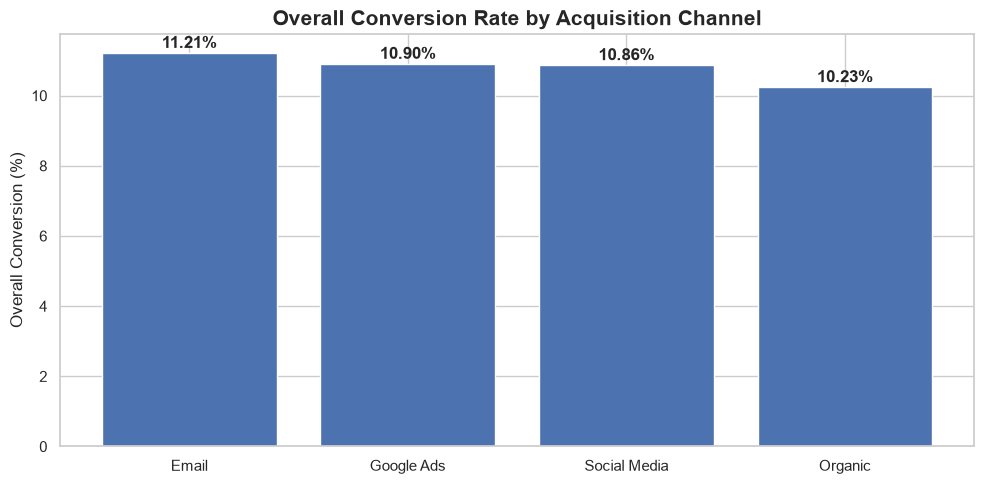

In [46]:
channel_funnel = funnel_by_dimension("Channel")
display(channel_funnel.round(2))

plt.figure(figsize=(10, 5))
plot = channel_funnel.reset_index()
x = np.arange(len(plot))
values = plot["Overall_Conversion"].values
plt.bar(x, values)
plt.xticks(x, plot["Channel"])
plt.ylabel("Overall Conversion (%)")
plt.title("Overall Conversion Rate by Acquisition Channel", fontsize=15, fontweight="bold")
for i, v in enumerate(values):
    plt.text(i, v + 0.15, f"{v:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Product Category Performance

Event,Browse,Add to Cart,Checkout,Purchase,Overall_Conversion,Browse_to_Cart,Cart_to_Checkout,Checkout_to_Purchase
Product_Category,,,,,,,,
Electronics,2046,1444,686,229,11.19,70.58,47.51,33.38
Fashion,2035,1435,707,223,10.96,70.52,49.27,31.54
Home,1941,1341,736,212,10.92,69.09,54.88,28.80
Sports,2000,1437,696,215,10.75,71.85,48.43,30.89
Beauty,1978,1402,699,201,10.16,70.88,49.86,28.76


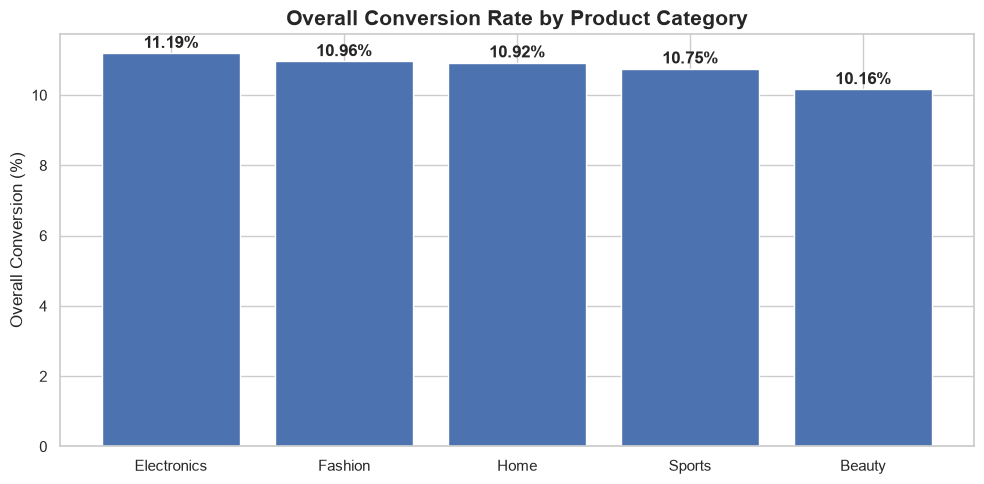

In [47]:
category_funnel = funnel_by_dimension("Product_Category")
display(category_funnel.round(2))

plt.figure(figsize=(10, 5))
plot = category_funnel.reset_index()
x = np.arange(len(plot))
values = plot["Overall_Conversion"].values
plt.bar(x, values)
plt.xticks(x, plot["Product_Category"])
plt.ylabel("Overall Conversion (%)")
plt.title("Overall Conversion Rate by Product Category", fontsize=15, fontweight="bold")
for i, v in enumerate(values):
    plt.text(i, v + 0.15, f"{v:.2f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 14. Revenue Analysis

In [48]:
purchase_df = df[df["Event"] == "Purchase"].copy()

revenue_summary = pd.Series({
    "Total Revenue": purchase_df["Revenue"].sum(),
    "Purchases": purchase_df["Session_ID"].nunique(),
    "Average Order Value": purchase_df["Revenue"].mean(),
    "Median Order Value": purchase_df["Revenue"].median(),
    "Minimum Order Value": purchase_df["Revenue"].min(),
    "Maximum Order Value": purchase_df["Revenue"].max()
})

display(revenue_summary.to_frame("Value"))

,Value
Total Revenue,"1,176,405.78"
Purchases,"1,080.00"
Average Order Value,"1,089.26"
Median Order Value,"1,099.83"
Minimum Order Value,201.26
Maximum Order Value,"1,998.51"


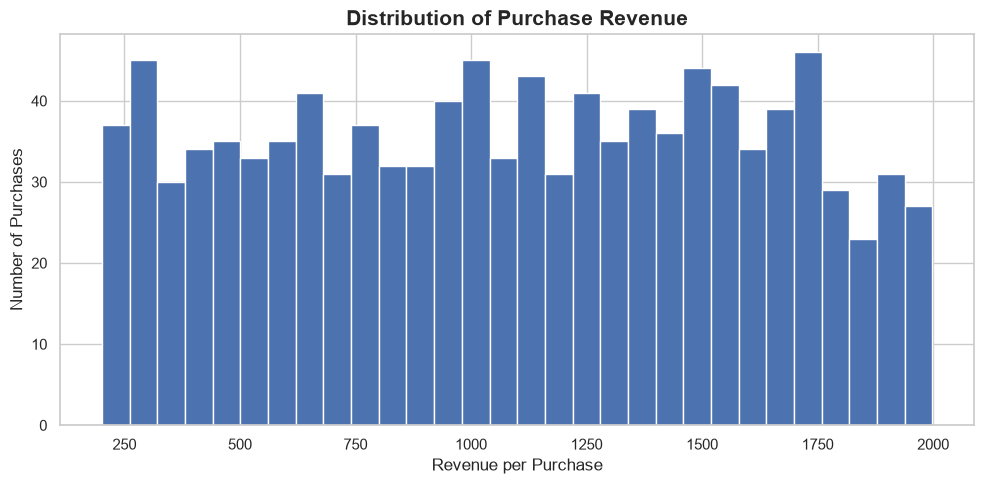

In [49]:
plt.figure(figsize=(10, 5))
plt.hist(purchase_df["Revenue"], bins=30)
plt.title("Distribution of Purchase Revenue", fontsize=15, fontweight="bold")
plt.xlabel("Revenue per Purchase")
plt.ylabel("Number of Purchases")
plt.tight_layout()
plt.show()

## 15. Key Business Insights

### Funnel performance
- **10,000** sessions started with a browse event.
- **7,059** reached Add to Cart, a **70.59%** Browse → Add to Cart conversion.
- **3,524** reached Checkout, a **49.92%** Add to Cart → Checkout conversion.
- **1,080** completed a Purchase, a **30.65%** Checkout → Purchase conversion.
- Overall Browse → Purchase conversion is **10.80%**.

### Bottlenecks
1. **Add to Cart → Checkout** loses **3,535 sessions**, the largest absolute drop-off.
2. **Checkout → Purchase** has the lowest conversion rate at **30.65%**, representing another major optimization opportunity.

### Segmentation
- Tablet sessions have the highest device-level overall conversion in this dataset.
- Email has the highest channel-level overall conversion among the listed channels.
- Electronics has the highest category-level overall conversion.

These findings are specific to the supplied dataset and should be validated against larger production data before making high-impact business decisions.

## 16. Recommendations to Increase Conversions

### Improve the cart transition
- Make cart contents and pricing clearer.
- Surface delivery charges and estimated arrival time earlier.
- Add strong, visible CTAs for moving to checkout.
- Test cart-page layout and urgency messaging.

### Reduce checkout abandonment
- Simplify the checkout process.
- Offer guest checkout.
- Provide multiple payment methods.
- Minimize form fields.
- Show trust, returns, and delivery information near the final purchase CTA.

### Optimize high-value segments
- Investigate why tablet and email traffic convert better.
- Compare landing pages, offers, and user intent across channels.
- Replicate successful product-page and checkout patterns in weaker segments.

### Continuous testing
Use A/B tests to measure whether changes improve Add-to-Cart, Checkout, and Purchase conversion rather than relying only on overall conversion.

## 17. Conclusion

The supplied e-commerce dataset shows a **10.80% overall Browse → Purchase conversion rate**. The most important losses occur between **Add to Cart → Checkout** and **Checkout → Purchase**. Focusing optimization efforts on cart clarity, checkout simplicity, payment flexibility, and trust signals should be the first business priority.

The analysis demonstrates the complete Data Analytics workflow: **data loading → quality checks → exploratory analysis → funnel metrics → segmentation → visualization → business insights → recommendations**.